**Task 1: Dataset Understanding**

In [119]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
# Unzipping uploaded dataset file

import zipfile

zip_path = '/content/part_3_nlp_sequence_modeling-20260517T063719Z-3-001.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully")

Dataset extracted successfully


In [121]:
# Loading NLP dataset

df = pd.read_csv('/content/dataset/part_3_nlp_sequence_modeling/customer_support_text_classification.csv')

In [122]:
# Displaying first 5 rows of dataset

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [123]:
# Checking number of rows and columns

print("Dataset Shape:", df.shape)

print("Number of Records:", df.shape[0])

print("Number of Columns:", df.shape[1])

Dataset Shape: (1500, 6)
Number of Records: 1500
Number of Columns: 6


In [124]:
# Displaying dataset columns

df.columns


Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

In [125]:
# Checking unique target labels

print(df['sentiment_label'].unique())

# Counting records in each target class

df['sentiment_label'].value_counts()

['neutral' 'positive' 'negative']


,count
sentiment_label,
neutral,524
negative,497
positive,479


In [126]:
# Displaying sample customer messages

df['customer_message'].head(5)

,customer_message
0,I need information about the payment process. ...
1,I need information about the payment process.
2,The refund process was fast and convenient. I ...
3,My refund is still pending and this experience...
4,Please tell me how to update my account details.


In [127]:
# Calculating average text length

average_length = df['customer_message'].apply(len).mean()

print("Average Text Length:", average_length)

Average Text Length: 72.75666666666666


/tmp/ipykernel_3092/74123119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


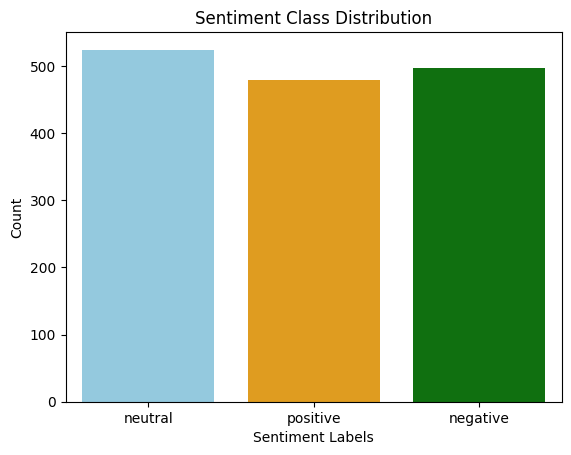

In [128]:
# Plotting sentiment class distribution

sns.countplot(
    x='sentiment_label',
    data=df,
    palette=['skyblue','orange','green']
)

plt.title("Sentiment Class Distribution")

plt.xlabel("Sentiment Labels")

plt.ylabel("Count")

plt.show()

**Observation**:

The dataset contains 1500 customer support text records with 6 columns. The target variable in the dataset is sentiment_label, which contains three sentiment classes: positive, negative, and neutral.

Sample customer messages were analyzed to understand the text structure and customer communication patterns. The average text length was calculated to understand the approximate size of customer messages in the dataset.

The class distribution graph was used to analyze how records are distributed across different sentiment categories. This dataset will be used for NLP preprocessing and sequence modeling tasks.

**Task 2: Text Preprocessing**

In [129]:
# Importing required libraries for NLP preprocessing

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [130]:
# Downloading required NLTK datasets

nltk.download('punkt')

nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [131]:
# Converting customer messages into lowercase

df['clean_text'] = df['customer_message'].str.lower()

In [132]:
# Removing unnecessary special characters and punctuation

df['clean_text'] = df['clean_text'].apply(

    lambda x: re.sub(r'[^\w\s]', '', x)
)

In [133]:
# Tokenizing text data into words

df['tokens'] = df['clean_text'].apply(word_tokenize)

In [134]:
# Defining English stopwords

stop_words = set(stopwords.words('english'))

# Removing stopwords from tokenized text

df['tokens'] = df['tokens'].apply(

    lambda words: [word for word in words if word not in stop_words]
)

In [135]:
# Displaying cleaned and tokenized text

df[['customer_message', 'clean_text', 'tokens']].head()

,customer_message,clean_text,tokens
0,I need information about the payment process. ...,i need information about the payment process m...,"[need, information, payment, process, ticket, ..."
1,I need information about the payment process.,i need information about the payment process,"[need, information, payment, process]"
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...,"[refund, process, fast, convenient, appreciate..."
3,My refund is still pending and this experience...,my refund is still pending and this experience...,"[refund, still, pending, experience, frustrati..."
4,Please tell me how to update my account details.,please tell me how to update my account details,"[please, tell, update, account, details]"


In [136]:
# Joining tokens into cleaned sentences

df['processed_text'] = df['tokens'].apply(

    lambda x: ' '.join(x)
)

In [137]:
# Creating tokenizer object

tokenizer = Tokenizer()

# Fitting tokenizer on processed text

tokenizer.fit_on_texts(df['processed_text'])

In [138]:
# Converting text into numerical sequences

sequences = tokenizer.texts_to_sequences(df['processed_text'])

In [139]:
# Padding sequences to fixed length

padded_sequences = pad_sequences(

    sequences,

    maxlen=50,

    padding='post',

    truncating='post'
)

print("Padded Sequence Shape:", padded_sequences.shape)

Padded Sequence Shape: (1500, 50)


**Observation**:

The text data was successfully preprocessed for NLP modeling. Customer messages were first converted into lowercase to maintain consistency in text representation.

Special characters, punctuation marks, and unnecessary symbols were removed to clean the text data. Tokenization was performed to split sentences into individual words, and stopwords such as common English filler words were removed to keep only meaningful words.

The cleaned text was then converted into numerical sequences using a tokenizer because deep learning models cannot directly process raw text. Finally, padding was applied to ensure that all text sequences had equal length for sequence-based deep learning models.

**Task 3: Text Vectorization**

In [140]:
# Importing required libraries for text vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

In [141]:
# Creating TF-IDF vectorizer object

tfidf = TfidfVectorizer()

# Converting processed text into TF-IDF vectors

X_tfidf = tfidf.fit_transform(df['processed_text'])

In [142]:
# Checking shape of TF-IDF vectors

print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (1500, 633)


In [143]:
# Displaying sample TF-IDF feature names

print(tfidf.get_feature_names_out()[:20])

['10347' '10565' '10632' '10783' '10841' '10973' '11045' '11058' '11213'
 '11482' '11855' '12223' '12238' '12408' '12727' '12970' '13030' '13329'
 '13544' '13589']


In [144]:
# Displaying first text vector

print(X_tfidf[0].toarray())

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.   

**Explanation**:

Text data cannot be directly processed by machine learning or deep learning models because models work only with numerical values. Therefore, text must be converted into numerical vectors before training.

In this project, TF-IDF (Term Frequency - Inverse Document Frequency) vectorization was used to convert customer messages into numerical form. TF-IDF assigns importance scores to words based on how frequently they appear in a document compared to the entire dataset.

Words that appear frequently in a particular text but less frequently across the dataset receive higher importance scores. This helps the model focus on meaningful words while reducing the importance of very common words.

Text vectorization is an important NLP step because it transforms unstructured text into structured numerical data that machine learning and sequence models can understand.


The customer support text data was successfully converted into numerical vectors using TF-IDF vectorization. The TF-IDF matrix shape shows the number of text records and the total number of unique words/features generated from the dataset.

The vectorized representation converts textual information into structured numerical format, which can now be used for machine learning and deep learning models for NLP tasks such as sentiment classification and sequence modeling.

**Observation**:
The TF-IDF vectorization process successfully converted customer support text into numerical feature vectors. The vectorized representation helped transform unstructured text into structured numerical data that can be processed by machine learning models for sentiment classification.

**Task 4: Baseline Model**

In [145]:
# Importing required libraries for baseline model

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [146]:
# Defining input features and target variable

X = X_tfidf

y = df['sentiment_label']

In [147]:
# Splitting dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42
)

In [148]:
# Creating Logistic Regression model

model = LogisticRegression()

# Training model

model.fit(X_train, y_train)

LogisticRegression()

In [149]:
# Predicting sentiment labels on test data

y_pred = model.predict(X_test)

In [150]:
# Calculating model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [151]:
# Displaying classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



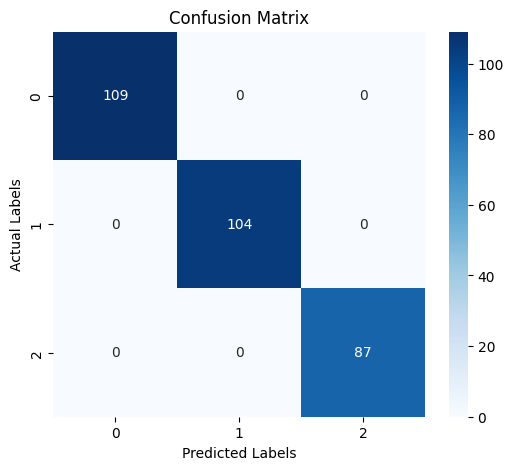

In [152]:
# Creating confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Plotting confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Labels")

plt.ylabel("Actual Labels")

plt.show()

**Observation**:

The baseline Logistic Regression model performed extremely well on the TF-IDF vectorized text data. The model achieved 100% accuracy on the testing dataset, which shows that it was able to correctly classify customer support messages into negative, neutral, and positive sentiment categories.

The confusion matrix shows that all records were classified correctly without any misclassification between sentiment classes. Similarly, the classification report shows precision, recall, and F1-score values of 1.00 for all three classes, indicating excellent model performance.

This result suggests that the TF-IDF vectorization method was highly effective in capturing important keywords and text patterns from customer messages. The Logistic Regression model was able to clearly separate sentiment categories based on the textual features present in the dataset.

Overall, the baseline NLP model performed very strongly and demonstrated how traditional machine learning techniques combined with text vectorization can effectively solve sentiment classification problems.

**Task 5: Sequence Model or Conceptual Architecture**

In [153]:
# Importing required libraries for LSTM model

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from sklearn.preprocessing import LabelEncoder

In [154]:
# Encoding sentiment labels into numerical form

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(df['sentiment_label'])

In [155]:
# Splitting padded sequences into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(

    padded_sequences,

    y_encoded,

    test_size=0.2,

    random_state=42
)

In [156]:
# Creating LSTM sequence model

lstm_model = Sequential()

# ==========================================
# Embedding Layer
# ==========================================

lstm_model.add(

    Embedding(

        input_dim=5000,

        output_dim=64,

        input_shape=(50,)
    )
)

# ==========================================
# LSTM Layer
# ==========================================

lstm_model.add(

    LSTM(64)
)

# Dropout Layer

lstm_model.add(

    Dropout(0.5)
)

# ==========================================
# Output Layer
# ==========================================

lstm_model.add(

    Dense(3, activation='softmax')
)

# Building model

lstm_model.build(input_shape=(None,50))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [157]:
# Compiling LSTM model

lstm_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [158]:
# Displaying LSTM model summary

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,219 (1.35 MB)

 Trainable params: 353,219 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

**Observation**:

The LSTM sequence model architecture was successfully created for sentiment classification of customer support messages. The model summary shows that the architecture contains an Embedding layer, LSTM layer, Dropout layer, and Dense output layer.

The Embedding layer converts input text sequences into dense numerical word representations, allowing the model to learn semantic relationships between words. The LSTM layer processes the text sequentially and helps capture contextual meaning and dependencies between words in a sentence.

The model contains a total of 353,219 trainable parameters, which will be updated during training to improve sentiment prediction performance. The final Dense output layer contains 3 neurons with Softmax activation for classifying customer messages into negative, neutral, and positive sentiment categories.

Overall, the sequence model architecture demonstrates how deep learning models process textual input step by step using embeddings and recurrent sequence learning techniques for NLP tasks.

**Task 6: Attention and Transformer Reflection**

Task 6: Attention and Transformer Reflection

1. Why do RNNs struggle with long-term dependencies?

RNNs process text one word at a time and try to pass information from previous words to the next step. The problem is that when sentences become very long, the model slowly starts forgetting earlier information. This makes it difficult for RNNs to remember important context from the beginning of the sentence.

For example, in a long customer complaint message, the important issue may be mentioned at the start, but while processing later words the RNN may lose that information. Because of this, traditional RNNs are not very effective for handling long text sequences.

---

2. How do LSTMs help with memory?

LSTMs were introduced to solve the memory problem of normal RNNs. They contain special memory cells and gates that help the model decide which information should be remembered and which should be ignored.

This helps the model keep important context for a longer time while processing text. For example, while analyzing customer support messages, the LSTM can remember important words from earlier parts of the sentence and use that information for better sentiment prediction.

Because of this improved memory handling, LSTMs usually perform much better than traditional RNNs in NLP tasks.

---

3. What problem does Attention solve in sequence-to-sequence tasks?

In tasks like language translation or text summarization, older sequence models tried to store the entire sentence meaning into one fixed representation. This sometimes caused loss of important information, especially for long sentences.

Attention helps solve this problem by allowing the model to focus more on important words while generating the output. Instead of treating every word equally, the model can “pay attention” to the most relevant parts of the input sentence at each step.

For example, during translation, the model can focus on important words related to the current word being generated, which improves overall accuracy and understanding.

---

4. Why are Transformers important in modern NLP and Generative AI?

Transformers are very important in modern NLP because they can process text much faster and understand context better compared to older models like RNNs and LSTMs. They use a self-attention mechanism, which helps the model understand relationships between words even if they are far apart in the sentence.

Transformers are the foundation of modern Generative AI systems such as ChatGPT, Gemini, and other large language models. These models are widely used for chatbots, text generation, translation, summarization, question answering, and many other AI applications.

Their ability to understand context, process large amounts of text, and generate human-like responses has made transformers one of the most important technologies in AI today.